# Proyecto de empresa aliada
## entregable 3

En esta práctica, aplicarás técnicas de clustering para identificar segmentos clave en los que la marca Vanish tiene presencia, y podrás identificar áreas en las que mejorar su estrategia.
*** 
* ### **Cargar y preparar los datos:**

    * Carga el conjunto de datos relevante en un DataFrame de Pandas.

    * Revisa los datos para identificar las columnas más relevantes que se utilizarán

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')


In [2]:
df_DIM_CALENDAR = pd.read_excel('DIM_CALENDAR (2).xlsx')
df_DIM_CATEGORY= pd.read_csv('DIM_CATEGORY (2).csv')
df_DIM_PRODUCT = pd.read_excel('DIM_PRODUCT (1).xlsx')
df_DIM_SEGMENT = pd.read_excel('DIM_SEGMENT (1).xlsx')
df_FACT_SALES = pd.read_csv('FACT_SALES (1).csv')

## Crear dataframe consolidado :
### Limpieza de datos:

In [3]:
# Pasos reciclados de ejercicio anterior para construir DF consolidado
df_DIM_SEGMENT['ATTR3'] = df_DIM_SEGMENT['ATTR3'].fillna('NO DEFINIDO')
df_DIM_CATEGORY['CATEGORY'] = df_DIM_CATEGORY['CATEGORY'].str.strip()
df_DIM_PRODUCT = df_DIM_PRODUCT.fillna('NO DEFINIDO')
df_SALES_PRODUCT = pd.merge(df_DIM_PRODUCT, df_FACT_SALES, left_on='ITEM', right_on='ITEM_CODE', how='inner') 
df_SALES_PRODUCT_SEGMENT = pd.merge(df_SALES_PRODUCT, df_DIM_SEGMENT, on= ['ATTR1', 'ATTR2', 'ATTR3','FORMAT'], how='left')
df_SALES_PRODUCT_SEGMENT_DATE = pd.merge(df_SALES_PRODUCT_SEGMENT, df_DIM_CALENDAR, on= ['WEEK'], how='left')
df_consolidado = df_SALES_PRODUCT_SEGMENT_DATE.drop(columns=['CATEGORY_y','ITEM_CODE','CATEGORY_x','WEEK'])

In [4]:
column_consolidado = [
    'MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'FORMAT',
    'ATTR1', 'ATTR2', 'ATTR3','REGION', 'SEGMENT', 'YEAR', 'MONTH',
    'WEEK_NUMBER', 'DATE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES',
    'TOTAL_UNIT_AVG_WEEKLY_SALES'
]

In [5]:
df_consolidado = df_consolidado[column_consolidado]

In [6]:
#Funcion para asignar Categorias
def newcat (Row): 
    if  (Row['ATTR1'] == 'CLORO') & (Row['ATTR3'] == 'NO DEFINIDO'):
        return 'MEGA SUPERFICIES'
    elif (Row['ATTR2'] == 'FABRIC TREATMENT') | (Row['ATTR2'] == 'SANITIZANTE'):
        return 'FABRIC TREATMENT and SANIT'
    else:
        return 'LAVATORY CARE & BRC'

In [7]:
df_consolidado['CATEGORIA'] = df_consolidado.apply(newcat, axis='columns')


In [8]:
df_consolidado

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,FORMAT,ATTR1,ATTR2,ATTR3,REGION,SEGMENT,YEAR,MONTH,WEEK_NUMBER,DATE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,CATEGORIA
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,11,45,2022-11-13,0.034,0.142,8.500,MEGA SUPERFICIES
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,11,45,2022-11-13,0.034,0.142,8.500,MEGA SUPERFICIES
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,12,48,2022-12-04,0.002,0.009,1.000,MEGA SUPERFICIES
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,12,48,2022-12-04,0.002,0.009,1.000,MEGA SUPERFICIES
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,1,3,2022-01-23,0.432,1.956,14.400,MEGA SUPERFICIES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152397,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2023,7,26,2023-07-03,0.013,0.692,1.300,MEGA SUPERFICIES
152398,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS AREA 2,BLEACH,2023,6,25,2023-06-26,0.013,0.720,1.083,MEGA SUPERFICIES
152399,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS AREA 2,BLEACH,2023,6,25,2023-06-26,0.013,0.720,1.083,MEGA SUPERFICIES
152400,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2023,6,25,2023-06-26,0.013,0.720,1.083,MEGA SUPERFICIES


***
* ### **Seleccionar las características para el clustering:**
    * Elige las características clave que se utilizarán para segmentar los productos o regiones. Por ejemplo, puedes basarte en:

        * Ventas totales 
    
        * Categoría de producto 
    
        * Región geográfica 
    
        * Atributos específicos de los productos 

In [10]:
#Datos para clustering: TOTAL_UNIT_SALES, TOTAL_VALUE_SALES, TOTAL_UNIT_AVG_WEEKLY_SALES
raw_data = df_consolidado.iloc[: ,[14,15,16]].values
raw_data = pd.DataFrame(raw_data,columns=['TOTAL_UNIT_SALES','TOTAL_VALUE_SALES','TOTAL_UNIT_AVG_WEEKLY_SALES'] ) 
normal_data = pd.DataFrame(raw_data,columns=['TOTAL_UNIT_SALES','TOTAL_VALUE_SALES','TOTAL_UNIT_AVG_WEEKLY_SALES'] ) 
raw_data

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
0,0.034,0.142,8.500
1,0.034,0.142,8.500
2,0.002,0.009,1.000
3,0.002,0.009,1.000
4,0.432,1.956,14.400
...,...,...,...
152397,0.013,0.692,1.300
152398,0.013,0.720,1.083
152399,0.013,0.720,1.083
152400,0.013,0.720,1.083


*** 
* ### Aplicar el algoritmo K-Means:

    * Elige un número inicial de clusters (por ejemplo, 3 o 4) y aplica el algoritmo K-Means usando Scikit-learn.

    * Realiza varias iteraciones con diferentes números de clusters para determinar cuál es el óptimo. Puedes utilizar el **método del codo** para evaluar qué número de clusters minimiza la suma de las distancias al centroide de cada cluster.

### Sin Normalizar:

In [11]:
from sklearn import decomposition
pca = decomposition.PCA(n_components=2)
pca.fit(raw_data)
raw_data = pca.transform(raw_data)
raw_data

array([[-109.38184444,   -1.55207682],
       [-109.38184444,   -1.55207682],
       [-109.69156919,   -9.03279025],
       ...,
       [-108.97891679,   -8.96764535],
       [-108.97891679,   -8.96764535],
       [-108.97891679,   -8.96764535]], shape=(152402, 2))

In [12]:
wcss = []
for index in range (1,11):
    kmeans = KMeans(n_clusters= index, init = 'k-means++', random_state = 2)
    kmeans.fit (raw_data)

    wcss.append(kmeans.inertia_)

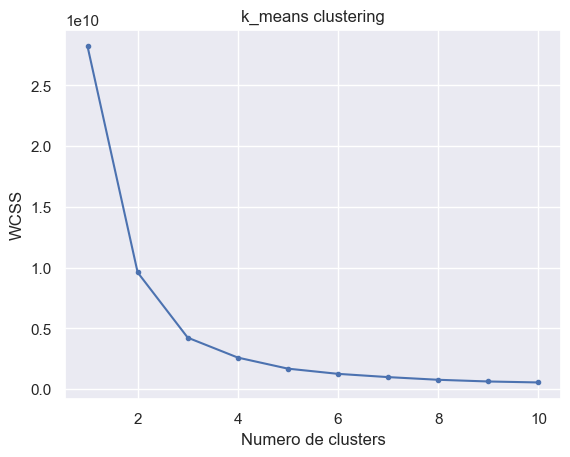

In [13]:
# Graficacion del "Codo de Jambu"
sns.set()
plt.plot(range(1,11), wcss, marker='.')
plt.title('k_means clustering')
plt.xlabel('Numero de clusters')
plt.ylabel('WCSS') # Weighted cluster sum of squares
plt.show()

In [14]:
kmeans = KMeans(n_clusters= 3, init= 'k-means++', random_state = 42)
cluster_values= kmeans.fit_predict(raw_data)
print(cluster_values)

[0 0 0 ... 0 0 0]


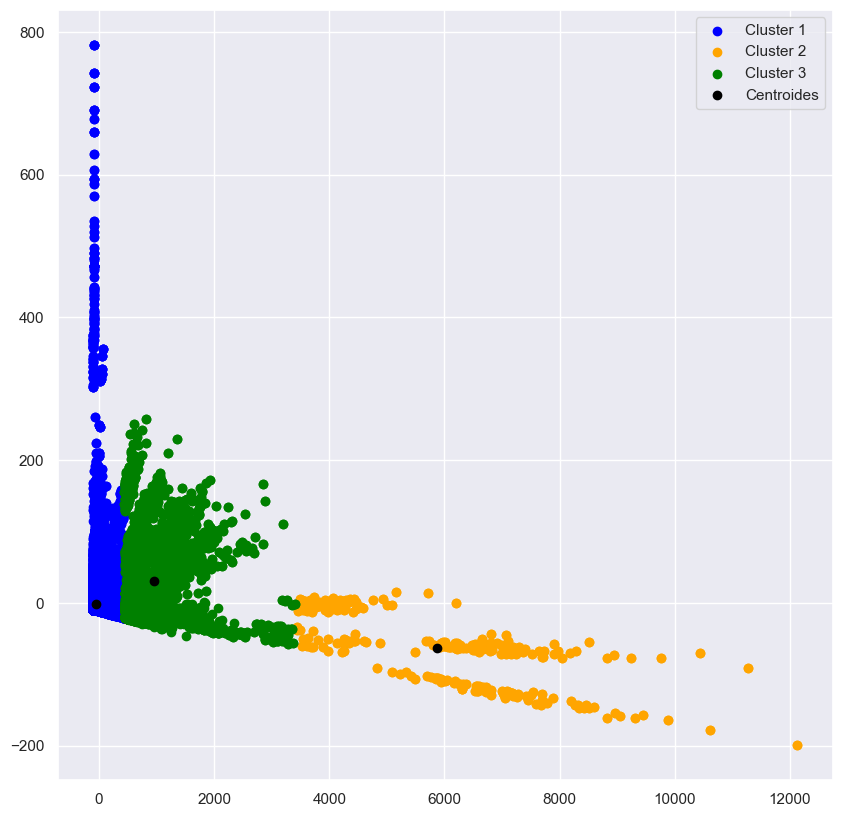

In [15]:
plt.figure(figsize= (10,10))
plt.scatter(raw_data[cluster_values == 0,0], raw_data[cluster_values == 0,1], c = 'blue', label = 'Cluster 1')
plt.scatter(raw_data[cluster_values == 1,0], raw_data[cluster_values == 1,1], c = 'orange', label = 'Cluster 2')
plt.scatter(raw_data[cluster_values == 2,0], raw_data[cluster_values == 2,1], c = 'green', label = 'Cluster 3')


plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c = 'black',label = 'Centroides')

plt.legend()

***

### Normalizado

Se muestra que no existe una gran diferencia entre los datos crudos y normalizados, sin embargo el proceso continuara usando los datos Normalizados para mejorar el desempeño del modelo. 

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
print(scaler.fit(normal_data))

StandardScaler()


In [17]:
scaled_data = scaler.transform(normal_data)
scaled_data

array([[-0.22775957, -0.25465534, -0.14859319],
       [-0.22775957, -0.25465534, -0.14859319],
       [-0.22956369, -0.25496538, -0.41880633],
       ...,
       [-0.22894352, -0.25330794, -0.41581597],
       [-0.22894352, -0.25330794, -0.41581597],
       [-0.22894352, -0.25330794, -0.41581597]], shape=(152402, 3))

In [18]:
from sklearn import decomposition
pca2 = decomposition.PCA(n_components=2)
pca2.fit(scaled_data)
scaled_data = pca2.transform(scaled_data)
scaled_data

array([[-0.3717973 ,  0.01068682],
       [-0.3717973 ,  0.01068682],
       [-0.48740066, -0.23323451],
       ...,
       [-0.48468261, -0.2312474 ],
       [-0.48468261, -0.2312474 ],
       [-0.48468261, -0.2312474 ]], shape=(152402, 2))

In [19]:
wcss2 = []
for index in range (1,11):
    kmeans2 = KMeans(n_clusters= index, init = 'k-means++', random_state = 2)
    kmeans2.fit (scaled_data)

    wcss2.append(kmeans2.inertia_)

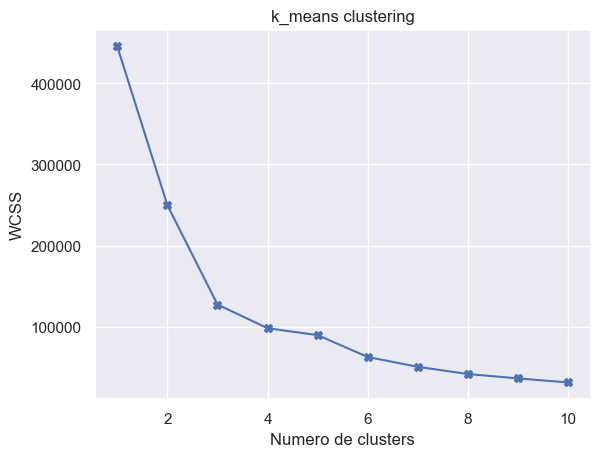

In [20]:
# Graficacion del "Codo de Jambu"
sns.set()
plt.plot(range(1,11), wcss2, marker='X')
plt.title('k_means clustering')
plt.xlabel('Numero de clusters')
plt.ylabel('WCSS') # Weighted cluster sum of squares
plt.show()

In [21]:

kmeans2 = KMeans(n_clusters= 3, init= 'k-means++', random_state = 2)
cluster_values= kmeans2.fit_predict(scaled_data)
print(cluster_values)

[1 1 1 ... 1 1 1]


## Numero de Clusters se define en 3 usando como referencia el codo de Jambu
Se puede observar que despues de este numero ya no existe un cambio fuerte entre el WCSS y el numero de clusters

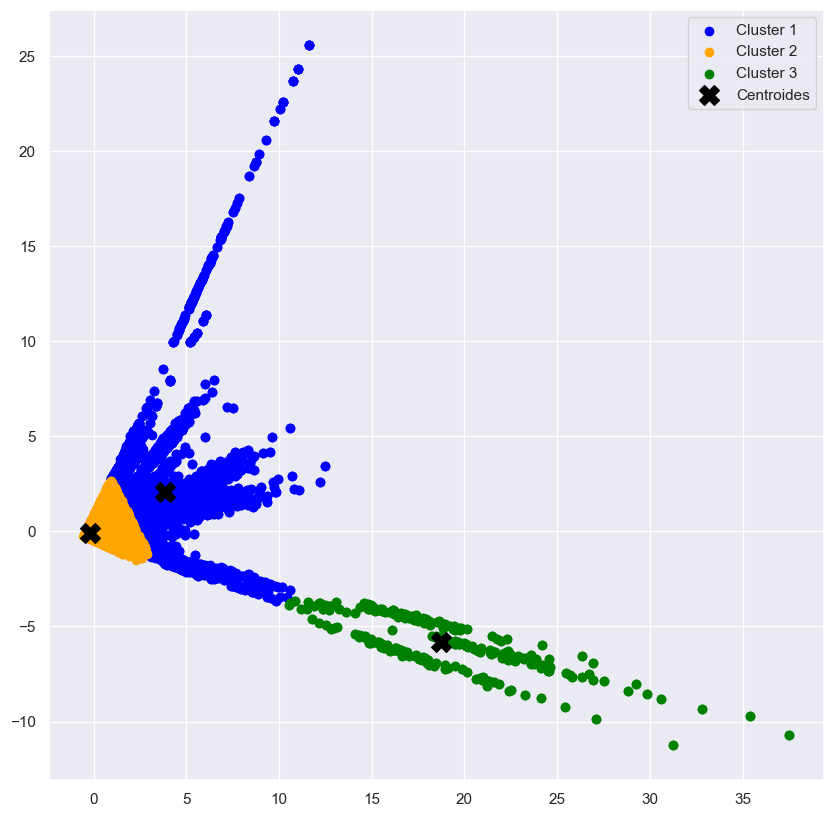

In [22]:
plt.figure(figsize= (10,10))
plt.scatter(scaled_data[cluster_values == 0,0], scaled_data[cluster_values == 0,1], c = 'blue', label = 'Cluster 1')
plt.scatter(scaled_data[cluster_values == 1,0], scaled_data[cluster_values == 1,1], c = 'orange', label = 'Cluster 2')
plt.scatter(scaled_data[cluster_values == 2,0], scaled_data[cluster_values == 2,1], c = 'green', label = 'Cluster 3')

plt.scatter(kmeans2.cluster_centers_[:,0],kmeans2.cluster_centers_[:,1], c = 'black',label = 'Centroides',marker='X',s=200,)
plt.legend()

### Gráfico final visualizando los 3 grupos junto con sus respectivos centroides. 

***

* ### Evaluar los resultados del clustering:

    * Revisa los resultados obtenidos y asigna cada producto o región a un cluster. Cada cluster debe representar un grupo de productos o regiones con características similares.

    * Analiza las características de cada cluster y observa si hay patrones o segmentos que destacan en las ventas, categoría o región.

### Se procede a unir el cluster al datata frame principal y generar graficos:

In [23]:
#Asignando Clusters a Data frame principal
df_consolidado['CLUSTER'] = cluster_values
df_consolidado

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,FORMAT,ATTR1,ATTR2,ATTR3,REGION,SEGMENT,YEAR,MONTH,WEEK_NUMBER,DATE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,CATEGORIA,CLUSTER
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,11,45,2022-11-13,0.034,0.142,8.500,MEGA SUPERFICIES,1
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,11,45,2022-11-13,0.034,0.142,8.500,MEGA SUPERFICIES,1
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,12,48,2022-12-04,0.002,0.009,1.000,MEGA SUPERFICIES,1
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,12,48,2022-12-04,0.002,0.009,1.000,MEGA SUPERFICIES,1
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,1,3,2022-01-23,0.432,1.956,14.400,MEGA SUPERFICIES,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152397,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2023,7,26,2023-07-03,0.013,0.692,1.300,MEGA SUPERFICIES,1
152398,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS AREA 2,BLEACH,2023,6,25,2023-06-26,0.013,0.720,1.083,MEGA SUPERFICIES,1
152399,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS AREA 2,BLEACH,2023,6,25,2023-06-26,0.013,0.720,1.083,MEGA SUPERFICIES,1
152400,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2023,6,25,2023-06-26,0.013,0.720,1.083,MEGA SUPERFICIES,1


In [24]:
df_consolidado['CLUSTER'].value_counts()

CLUSTER
1    146134
0      5748
2       520
Name: count, dtype: int64

## Se muestra que de los 3 clusters (0,1,2 ) el numero 1 es por mucho el mas abundante con mas de 140,000 registros, seguido del cluster 0 con 5748 y por el ultimo el 2 con 520

In [25]:
df_consolidado.groupby('CLUSTER')[['TOTAL_UNIT_SALES','TOTAL_VALUE_SALES','TOTAL_UNIT_AVG_WEEKLY_SALES']].mean()

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
CLUSTER,,,
0,37.881117,880.663068,109.868190
1,1.874613,58.064305,8.536886
2,248.404358,6005.599069,86.388423


In [26]:
df_vanish = df_consolidado[df_consolidado['BRAND'] == 'VANISH']
df_vanish[['ITEM', 'ITEM_DESCRIPTION', 'CATEGORIA', 'CLUSTER']].drop_duplicates()

,ITEM,ITEM_DESCRIPTION,CATEGORIA,CLUSTER
60395,7501058712813,VANISH OXI ACTION QUITAMANCHAS P/ROPA BOTE 240...,FABRIC TREATMENT and SANIT,1
60581,7501058713780,VANISH OXI ACTION ROSA QUITA MANCHAS PARA LA R...,FABRIC TREATMENT and SANIT,1
60666,7501058714596,VANISH SUPER BARRA QUITA MANCHAS 68GR 75010587...,FABRIC TREATMENT and SANIT,1
60673,7501058714596,VANISH SUPER BARRA QUITA MANCHAS 68GR 75010587...,FABRIC TREATMENT and SANIT,0
61226,7501058715012,VANISH OXI ACTION CRISTAL WHITE BOT 150GR 7501...,FABRIC TREATMENT and SANIT,1
...,...,...,...,...
148645,7702626213781,VANISH OXI ACTION CRISTAL WHITE DOYPACK 240 GR...,FABRIC TREATMENT and SANIT,1
149205,7891035040191,VANISH QUITAMANCHAS PRELAVADOR BARRA 75GR 7891...,FABRIC TREATMENT and SANIT,1
149508,7891035040276,VANISH SUPER BARRA WHITE QUITA MANCHAS 68GR 78...,FABRIC TREATMENT and SANIT,1
149571,7891035040276,VANISH SUPER BARRA WHITE QUITA MANCHAS 68GR 78...,FABRIC TREATMENT and SANIT,0


### Basándonos en estos ultimos datos, podemos interpretar que los valores del clúster 1 son productos de bajo valor, pero de mucho volumen. el clúster 0 son productos más caros, pero de volumen mucho mas bajo, y los productos del cluster 2, casi no se venden a comparación de los demás, pero generan muchas ganancias.

In [27]:
df_cluster2 = df_consolidado[df_consolidado['CLUSTER'] == 1]
df_cluster2

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,FORMAT,ATTR1,ATTR2,ATTR3,REGION,SEGMENT,YEAR,MONTH,WEEK_NUMBER,DATE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,CATEGORIA,CLUSTER
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,11,45,2022-11-13,0.034,0.142,8.500,MEGA SUPERFICIES,1
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,11,45,2022-11-13,0.034,0.142,8.500,MEGA SUPERFICIES,1
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,12,48,2022-12-04,0.002,0.009,1.000,MEGA SUPERFICIES,1
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,12,48,2022-12-04,0.002,0.009,1.000,MEGA SUPERFICIES,1
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2022,1,3,2022-01-23,0.432,1.956,14.400,MEGA SUPERFICIES,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152397,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2023,7,26,2023-07-03,0.013,0.692,1.300,MEGA SUPERFICIES,1
152398,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS AREA 2,BLEACH,2023,6,25,2023-06-26,0.013,0.720,1.083,MEGA SUPERFICIES,1
152399,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS AREA 2,BLEACH,2023,6,25,2023-06-26,0.013,0.720,1.083,MEGA SUPERFICIES,1
152400,CLOROX,CLOROX,7502240948188BP1,CLOROX BLANQ930M+MMBLANQINOD709M+MMFIBRAULTRA1...,LIQUIDO,CLORO,CLORO,NO DEFINIDO,TOTAL AUTOS SCANNING MEXICO,BLEACH,2023,6,25,2023-06-26,0.013,0.720,1.083,MEGA SUPERFICIES,1


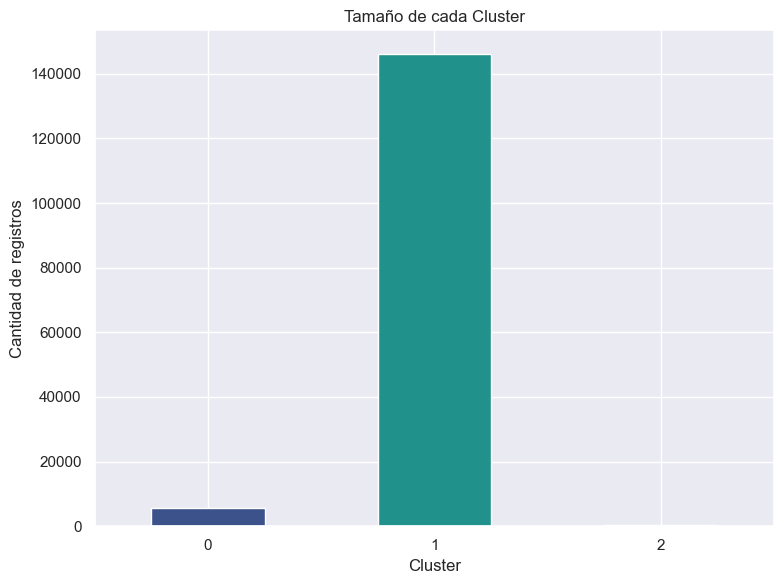

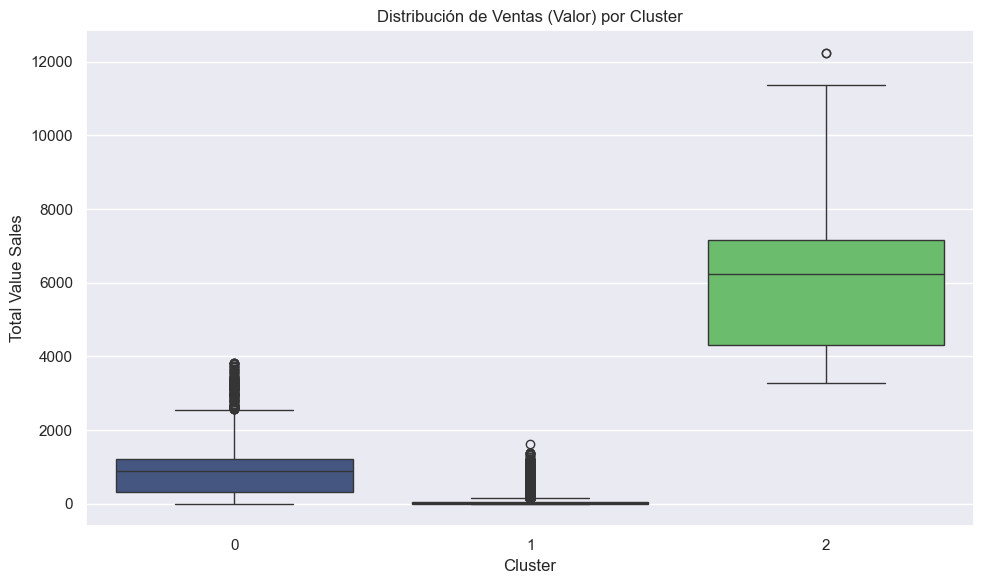

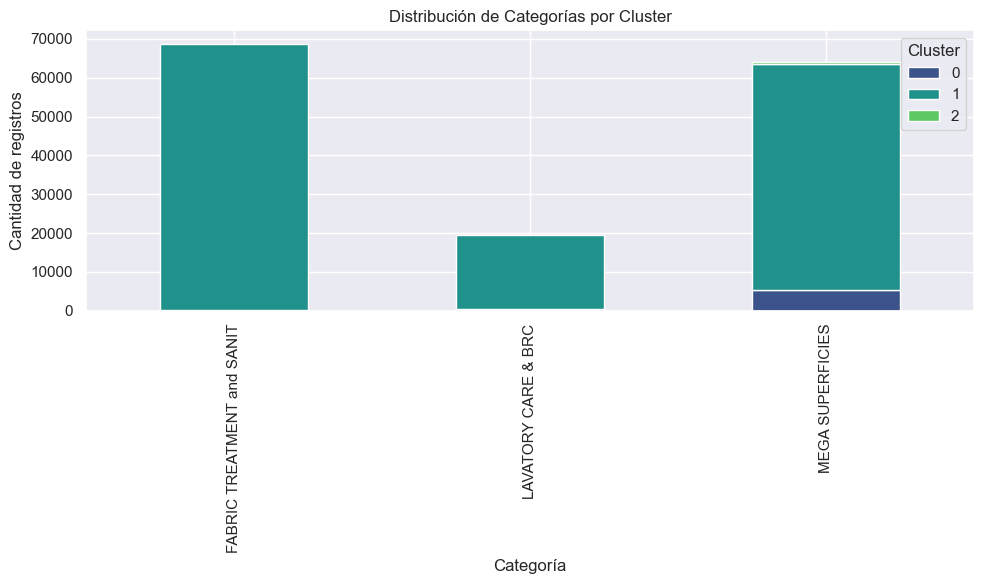

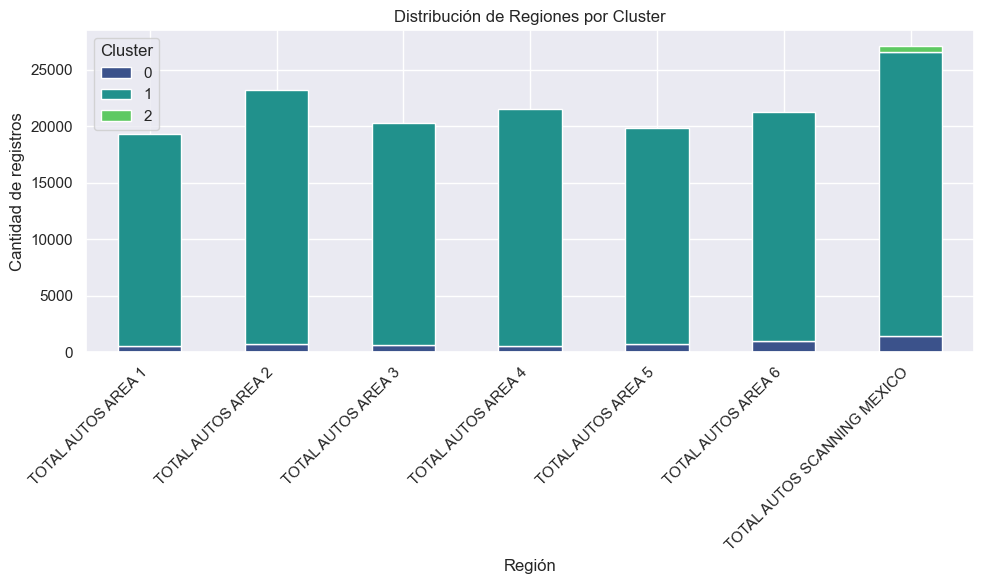

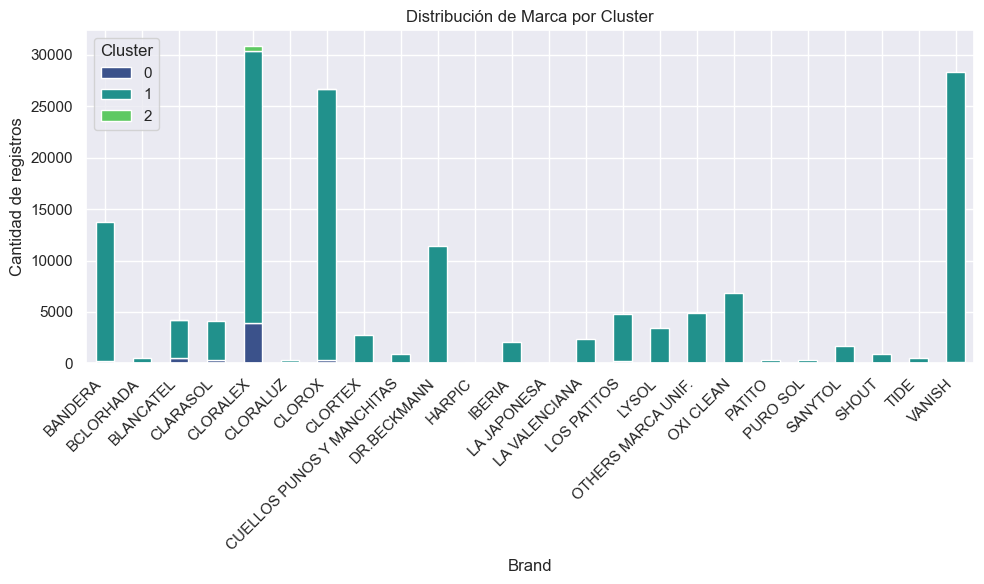

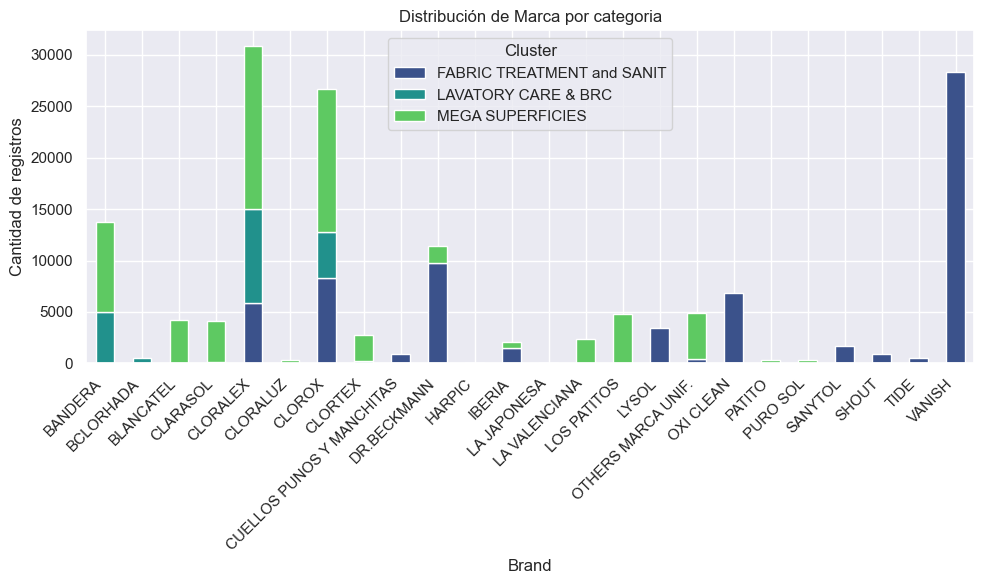

In [31]:
# Graficas:


# TAMAÑO CLUSTERS
plt.figure(figsize=(8,6))
df_consolidado['CLUSTER'].value_counts().sort_index().plot(kind='bar', color=sns.color_palette('viridis', n_colors=df_consolidado['CLUSTER'].nunique()))
plt.title('Tamaño de cada Cluster')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# VALOR VENTAS vs CLUSTER
plt.figure(figsize=(10,6))
sns.boxplot(x='CLUSTER', y='TOTAL_VALUE_SALES', data=df_consolidado, palette='viridis')
plt.title('Distribución de Ventas (Valor) por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Value Sales')
plt.tight_layout()
plt.show()

# CATEGORIA vs CLUSTER
crosstab_cat = pd.crosstab(df_consolidado['CATEGORIA'], df_consolidado['CLUSTER'])
crosstab_cat.plot(kind='bar', stacked=True, figsize=(10,6),
                   color=sns.color_palette('viridis', n_colors=crosstab_cat.shape[1]))
plt.title('Distribución de Categorías por Cluster')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de registros')
plt.legend(title='Cluster')
#plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# REGION vs CLUSTER
crosstab_reg = pd.crosstab(df_consolidado['REGION'], df_consolidado['CLUSTER'])
crosstab_reg.plot(kind='bar', stacked=True, figsize=(10,6),
                   color=sns.color_palette('viridis', n_colors=crosstab_reg.shape[1]))
plt.title('Distribución de Regiones por Cluster')
plt.xlabel('Región')
plt.ylabel('Cantidad de registros')
plt.legend(title='Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# BRAND vs CLUSTER
crosstab_reg = pd.crosstab(df_consolidado['BRAND'], df_consolidado['CLUSTER'])
crosstab_reg.plot(kind='bar', stacked=True, figsize=(10,6),
                   color=sns.color_palette('viridis', n_colors=crosstab_reg.shape[1]))
plt.title('Distribución de Marca por Cluster')
plt.xlabel('Brand')
plt.ylabel('Cantidad de registros')
plt.legend(title='Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# BRAND vs CATEGORIA
crosstab_reg = pd.crosstab(df_consolidado['BRAND'], df_consolidado['CATEGORIA'])
crosstab_reg.plot(kind='bar', stacked=True, figsize=(10,6),color=sns.color_palette('viridis', n_colors=crosstab_reg.shape[1]))
plt.title('Distribución de Marca por categoria')
plt.xlabel('Brand')
plt.ylabel('Cantidad de registros')
plt.legend(title='Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* ### Interpretar y analizar los clusters:

    * Documenta los insights clave de los resultados. Por ejemplo, ¿hay segmentos donde la marca Vanish tiene un fuerte desempeño? ¿Qué clusters muestran un rendimiento bajo o áreas de mejora?

    * Identifica si existen patrones en los productos o regiones que puedan influir en la estrategia comercial. Por ejemplo, si un cluster contiene productos con ventas bajas, ¿hay alguna característica en común que podría explicar ese desempeño?

## Puntos clave

* Interpretando las graficas podemos entender que el clúster 2 pertenece solo a la categoría de “MEGA SUPERFICIES”, solo se venden en la región “TOTAL AUTOS SCANNING MEXICO”, generan más valor de ventas que los otros clústeres juntos, solo son de marca “CLORALEX” y parecen ser productos de mucho volumen como “CLOROX REGULAR CONCENTRADO BOTPLAST.3800ML”. 

    El clúster 0, parecen ser productos más grandes, como CLORALEX EL RENDIDOR BOT.PLAST. 500ML, la mayoría son marca “CLORALEX”, se venden muy poco en todas las regiones, pero generan más ingresos que el clúster 1, pero no tanto como el 2. 

    Por último, el clúster 1, representa el 95.88% de todo el data frame, parecen ser productos chicos como “CLORALEX EL RENDIDOR BOT.PLAST. 250ML”, generan pocas ganancias, pero se venden mucho volumen en todas las regiones, categorías y marcas.

* Las marcas con mejores ventas son Cloralex, Clorox en la categoría de “Mega superficies”, Vanish en “FABRIC TREATMENT and SANIT".
